# Homework 5: Precipitation Nowcasting using Neural Networks

In this exercise, you are going to build a set of deep learning models on a real world task using PyTorch. PyTorch is an open source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab (FAIR).

## Setting up to use the gpu  

Before we start, we need to change the environment of Colab to use GPU. Do so by:

Runtime -> Change runtime type -> Hardware accelerator -> GPU

## Deep Neural Networks with PyTorch ##

To complete this exercise, you will need to build deep learning models for precipitation nowcasting. You will build a subset of the models shown below:
- Fully Connected (Feedforward) Neural Network
- Two-Dimentional Convolution Neural Network (2D-CNN)
- Recurrent Neural Network with Gated Recurrent Unit (GRU)

and one more model of your choice to achieve the highest score possible.

We provide the code for data cleaning and some starter code for PyTorch in this notebook but feel free to modify those parts to suit your needs. Feel free to use additional libraries (e.g. scikit-learn) as long as you have a model for each type mentioned above.

This notebook assumes you have already installed PyTorch with python3 and had GPU enabled. If you run this exercise on Colab you are all set.

## Precipitation Nowcasting ##

Precipitation nowcasting is the the task of predicting the amount of rainfall in a certain region given some kind of sensor data.  The term nowcasting refers to tasks that try to predict the current or near future conditions (within 6 hours).

You will be given satellite images in 3 different bands covering a 5 by 5 region from different parts of Thailand. In other words, your input will be a 5x5x3 image. Your task is to predict the amount of rainfall in the center pixel. You will first do the prediction using just a simple fully-connected neural network that view each pixel as different input features.

Since the your input is basically an image, we will then view the input as an image and apply CNN to do the prediction. Finally, we can also add a time component since weather prediction can benefit greatly using previous time frames. Each data point actually contain 5 time steps, so each input data point has a size of 5x5x5x3 (time x height x width x channel), and the output data has a size of 5 (time). You will use this time information when you work with RNNs.

Finally, we would like to thank the Thai Meteorological Department for providing the data for this assignment.

In [1]:
!nvidia-smi

Wed Mar  4 17:42:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti     Off |   00000000:01:00.0  On |                  N/A |
|  0%   45C    P0             33W /  285W |    3133MiB /  12282MiB |     11%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# For summarizing and visualizing models
!pip install torchinfo
!pip install torchviz


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Weights and Biases

[Weights and Biases](https://docs.wandb.ai/company) (wandb) is an experiment tracking tool for machine learning. It can log and visualize experiments in real time. It supports many popular ML frameworks, and obviously PyTorch is one of them. In this notebook you will learn how to log general metrics like losses, parameter distributions, and gradient distribution with wandb.

To install wandb, run the cell below

In [3]:
!pip install wandb


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Setup

1. Register [Wandb account](https://wandb.ai/login?signup=true) (and confirm your email)

2. `wandb login` and copy paste the API key when prompt

In [1]:
import os
os.environ["WANDB_API_KEY"]="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"
os.environ["WANDB_MODE"] = "offline"
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [2]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import urllib
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from sklearn import preprocessing
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchinfo import summary
from tqdm.notebook import tqdm

torch.__version__

'2.10.0+cu128'

## Loading the data

The data is on huggingface, a website that allows people to share datasets and pretrained models.

In [6]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="ecitslos/HWnowcastingdata", filename="nowcastingHWdataset.tar.gz", repo_type="dataset", local_dir=".")

'nowcastingHWdataset.tar.gz'

In [7]:
!tar -xvf './nowcastingHWdataset.tar.gz'

dataset/features-m10.pk
dataset/features-m6.pk
dataset/features-m7.pk
dataset/features-m8.pk
dataset/features-m9.pk
dataset/labels-m10.pk
dataset/labels-m6.pk
dataset/labels-m7.pk
dataset/labels-m8.pk
dataset/labels-m9.pk


# Data Explanation #

The data is an hourly measurement of water vapor in the atmosphere, and two infrared measurements of cloud imagery on a latitude-longitude coordinate. Each measurement is illustrated below as an image. These three features are included as different channels in your input data.

<img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/wvapor.png" width="200"> <img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/cloud1.png" width="200"> <img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/cloud2.png" width="200">

We also provide the hourly precipitation (rainfall) records in the month of June, July, August, September, and October from weather stations spreaded around the country. A 5x5 grid around each weather station at a particular time will be paired with the precipitation recorded at the corresponding station as input and output data. Finally, five adjacent timesteps are stacked into one sequence.

The month of June-August are provided as training data, while the months of September and October are used as validation and test sets, respectively.


# Reading data

In [3]:
def read_data(months, data_dir='dataset'):
    features = np.array([], dtype=np.float32).reshape(0,5,5,5,3)
    labels = np.array([], dtype=np.float32).reshape(0,5)
    for m in months:
        filename = 'features-m{}.pk'.format(m)
        with open(os.path.join(data_dir,filename), 'rb') as file:
            features_temp = pickle.load(file)
        features = np.concatenate((features, features_temp), axis=0)

        filename = 'labels-m{}.pk'.format(m)
        with open(os.path.join(data_dir,filename), 'rb') as file:
            labels_temp = pickle.load(file)
        labels = np.concatenate((labels, labels_temp), axis=0)

    return features, labels

In [4]:
# use data from month 6,7,8 as training set
x_train, y_train = read_data(months=[6,7,8])

# use data from month 9 as validation set
x_val, y_val = read_data(months=[9])

# use data from month 10 as test set
x_test, y_test = read_data(months=[10])

print('x_train shape:',x_train.shape)
print('y_train shape:', y_train.shape, '\n')
print('x_val shape:',x_val.shape)
print('y_val shape:', y_val.shape, '\n')
print('x_test shape:',x_test.shape)
print('y_test shape:', y_test.shape)

/tmp/ipykernel_238631/1757501052.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  features_temp = pickle.load(file)
/tmp/ipykernel_238631/1757501052.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  labels_temp = pickle.load(file)


x_train shape: (229548, 5, 5, 5, 3)
y_train shape: (229548, 5) 

x_val shape: (92839, 5, 5, 5, 3)
y_val shape: (92839, 5) 

x_test shape: (111715, 5, 5, 5, 3)
y_test shape: (111715, 5)


**features**
- dim 0: number of entries
- dim 1: number of time-steps in ascending order
- dim 2,3: a 5x5 grid around rain-measued station
- dim 4: water vapor and two cloud imagenaries

**labels**
- dim 0: number of entries
- dim 1: number of precipitation for each time-step

# Three-Layer Feedforward Neural Networks

In [5]:
# Dataset need to be reshaped to make it suitable for feedforword model
def preprocess_for_ff(x_train, y_train, x_val, y_val):
    x_train_ff = x_train.reshape((-1, 5*5*3))
    y_train_ff = y_train.reshape((-1, 1))
    x_val_ff = x_val.reshape((-1, 5*5*3))
    y_val_ff = y_val.reshape((-1, 1))
    x_test_ff = x_test.reshape((-1, 5*5*3))
    y_test_ff = y_test.reshape((-1, 1))

    return x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff

x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff = preprocess_for_ff(x_train, y_train, x_val, y_val)
print(x_train_ff.shape, y_train_ff.shape)
print(x_val_ff.shape, y_val_ff.shape)
print(x_test_ff.shape, y_test_ff.shape)

(1147740, 75) (1147740, 1)
(464195, 75) (464195, 1)
(558575, 75) (558575, 1)


## Dataset

To prepare a DataLoader in order to feed data into the model, we need to create a `torch.utils.data.Dataset` object first. (Learn more about it [here](https://pytorch.org/docs/stable/data.html#map-style-datasets))

Dataset is a simple class that the DataLoader will get data from, most of its functionality comes from `__getitem__(self, index)` method, which will return a single data point (both input and label). In real world scenarios the method can do some other stuffs such as

1. Load images

If your input (x) are images. Oftentimes you won't be able to fit all the training images into your RAM. Thus, you should pass an array (or list) of image path into the dataloader, and the `__getitem__` will be the one who dynamically loads the actual image from the harddisk for you.

2. Data Normalization

Data normalization helps improve stability of training. Unnormalized data can cause gradients to explode. There are many variants of normalization, but in this notebook we will use either minmax or z-score (std) normalization. Read [this](https://developers.google.com/machine-learning/data-prep/transform/normalization) (or google) if you wish to learn more about data normalization.

3. Data Augmentation

In computer vision, you might want to apply small changes to the images you use in training (adjust brightness, contrast, rotation) so that the model will generalize better on unseen data. There are two kinds of augmentation: static and dynamic. Static augmentation will augment images and save to disk as a new dataset. On the other hand, rather than applying the change initially and use the same change on each image every epoch, dynamic augmentation will augment each data differently for each epoch. Note that augmentation is usually done on the CPU and you might be bounded by the CPU instead. PyTorch has a dedicated [documentation about data augmentation](https://pytorch.org/vision/master/transforms.html) if you want to know more.

### T1

Explain each line of code in the function preprocess_for_ff()

**Ans:** for X data set reshape the data to have `5*5*3` column since FeedForwardNN need Flat vector, for y data set its stacking all time steps together the FeedForwardNN will treat every single time step independently. 

In [6]:
class RainfallDatasetFF(Dataset):
    def __init__(self, x, y, normalizer):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)
        self.normalizer = normalizer
        print(self.x.shape)
        print(self.y.shape)

    def __getitem__(self, index):
        x = self.x[index] # Retrieve data
        x = self.normalizer.transform(x.reshape(1, -1)) # Normalize
        y = self.y[index]
        return x, y

    def __len__(self):
        return self.x.shape[0]

In [7]:
def normalizer_std(X):
    scaler = preprocessing.StandardScaler().fit(X)
    return scaler

def normalizer_minmax(X):
    scaler = preprocessing.MinMaxScaler().fit(X)
    return scaler

In [8]:
normalizer = normalizer_std(x_train_ff) # We will normalize everything based on x_train

train_dataset = RainfallDatasetFF(x_train_ff, y_train_ff, normalizer)
val_dataset = RainfallDatasetFF(x_val_ff, y_val_ff, normalizer)
test_dataset = RainfallDatasetFF(x_test_ff, y_test_ff, normalizer)

(1147740, 75)
(1147740, 1)
(464195, 75)
(464195, 1)
(558575, 75)
(558575, 1)


## DataLoader

DataLoader feeds data from our dataset into the model. We can freely customize batch size, data shuffle for each data split, and much more with DataLoader class. If you're curious about what can you do with PyTorch's DataLoader, you can check [this documentation](https://pytorch.org/docs/stable/data.html)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, pin_memory=True)

## Loss Function

PyTorch has many loss functions readily available for use. We can also write our own custom loss function as well. But for now, we will use [PyTorch's built-in mean squared error loss ](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

In [10]:
loss_fn = nn.MSELoss()

### T2

Why is the loss MSE?

**Ans:** MSE is use because this is a regression task where we predicting continuous values. squaring the err ensure that loss is non-negative and differentiable, and it penalizes larger errors more heavily than smaller one. This encourage the model to fit the data mean.

## Device

Unlike Tensorflow/Keras, PyTorch allows user to freely put any Tensor or objects (loss functions, models, optimizers, etc.) in CPU or GPU. By default, all objects created will be in CPU. In order to use GPU we will have to supply `device = torch.device("cuda")` into the objects to move it to GPU. You will usually see the syntax like `object.to(device)` for moving CPU object to GPU, or `o = Object(..., device=device)` to create the object in the GPU.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Model

Below, the code for creating a 3-layers fully connected neural network in PyTorch is provided. Run the code and make sure you understand what you are doing. Then, report the results.

In [12]:
class FeedForwardNN(nn.Module):
    def __init__(self, hidden_size=200):
        super(FeedForwardNN, self).__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hd1 = F.relu(self.ff1(x))
        hd2 = F.relu(self.ff2(hd1))
        y = F.relu(self.ff3(hd2))
        y = self.out(y)
        return y.reshape(-1, 1)

### T3

What is the activation function in the final dense layer? and why? Do you think there is a better activation function for the final layer?

**Ans:** The final activation function is ReLu, because with regression problem the ReLu is simple yet effect to activate when the output is >= 0.

In [13]:
# Hyperparameters and other configs
config = {
    'architecture': 'feedforward',
    'lr': 0.01,
    'hidden_size': 200,
    'scheduler_factor': 0.2,
    'scheduler_patience': 2,
    'scheduler_min_lr': 1e-4,
    'epochs': 10
}

# Model
model_ff = FeedForwardNN(hidden_size=config['hidden_size'])
model_ff = model_ff.to(device)
optimizer = torch.optim.Adam(model_ff.parameters(), lr=config['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    'min',
    factor=config['scheduler_factor'],
    patience=config['scheduler_patience'],
    min_lr=config['scheduler_min_lr']
)

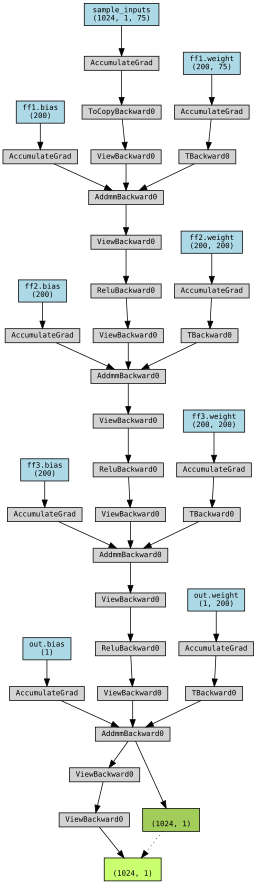

In [19]:
from torchviz import make_dot
# Visualize model with torchviz
sample_inputs = next(iter(train_loader))[0].requires_grad_(True)
sample_y = model_ff(sample_inputs.to(device))
make_dot(sample_y, params=dict(list(model_ff.named_parameters())+[('sample_inputs', sample_inputs)]))

In [20]:
summary(model_ff, input_size=(1024, 75))

Layer (type:depth-idx)                   Output Shape              Param #
FeedForwardNN                            [1024, 1]                 --
├─Linear: 1-1                            [1024, 200]               15,200
├─Linear: 1-2                            [1024, 200]               40,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
Total params: 95,801
Trainable params: 95,801
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 98.10
Input size (MB): 0.31
Forward/backward pass size (MB): 4.92
Params size (MB): 0.38
Estimated Total Size (MB): 5.61

### T4

Explain why the first linear layer has number of parameters = 15200

**Ans:** From the formula # of params = (in * out) + out = (75 * 200) + 200 = 15,200

# Training

In [21]:
train_losses = []
val_losses = []
learning_rates = []

# Start wandb run
wandb.init(
    project='precipitation-nowcasting-2026',
    config=config,
)

# Log parameters and gradients
# This makes the training slow. Do this when you are debugging only.
# You should avoid doing this when doing serious training.
wandb.watch(model_ff, log='all')

for epoch in range(config['epochs']):  # loop over the dataset multiple times

    # Training
    train_loss = []
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    # Flag model as training. Some layers behave differently in training and
    # inference modes, such as dropout, BN, etc.
    model_ff.train()

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer.zero_grad()

        # Predict
        y_pred = model_ff(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer.step()

        # Log stuff
        train_loss.append(loss)

    avg_train_loss = torch.stack(train_loss).mean().item()
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # Validation
    model_ff.eval()
    with torch.no_grad(): # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        val_loss = []
        for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_ff(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log stuff
            val_loss.append(loss)

        avg_val_loss = torch.stack(val_loss).mean().item()
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")

        # LR adjustment with scheduler
        scheduler.step(avg_val_loss)

        # Save checkpoint if val_loss is the best we got
        best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
        if avg_val_loss < best_val_loss:
            # Save whatever you want
            state = {
                'epoch': epoch,
                'model': model_ff.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'best_val_loss': best_val_loss,
            }

            print(f"Saving new best model..")
            torch.save(state, 'model_ff.pth.tar')

    wandb.log({
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'lr': current_lr,
    })

wandb.finish()
print('Finished Training')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: chatrin (chatrin-chulalongkorn-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training epoch 1...
Current LR: 0.01


  0%|          | 0/1121 [00:00<?, ?it/s]

Epoch 1 train loss: 1.9350
Validating epoch 1


  0%|          | 0/454 [00:00<?, ?it/s]

...

Epoch 10 train loss: 1.9200
Validating epoch 10


  0%|          | 0/454 [00:00<?, ?it/s]

Epoch 10 val loss: 1.6584


lr,████████▁▁
train_loss,█▂▃▁▁▂▂▁▁▁
val_loss,█▆▅▇▁▂▂▃▁▁
lr,0.002
train_loss,1.91997
val_loss,1.65844


Finished Training


You might want to download the saved model (model_ff.pth.tar) for later uses if you are running on Colab.

### T5

Plot loss and val_loss as a function of epochs.

In [14]:
import matplotlib.pyplot as plt

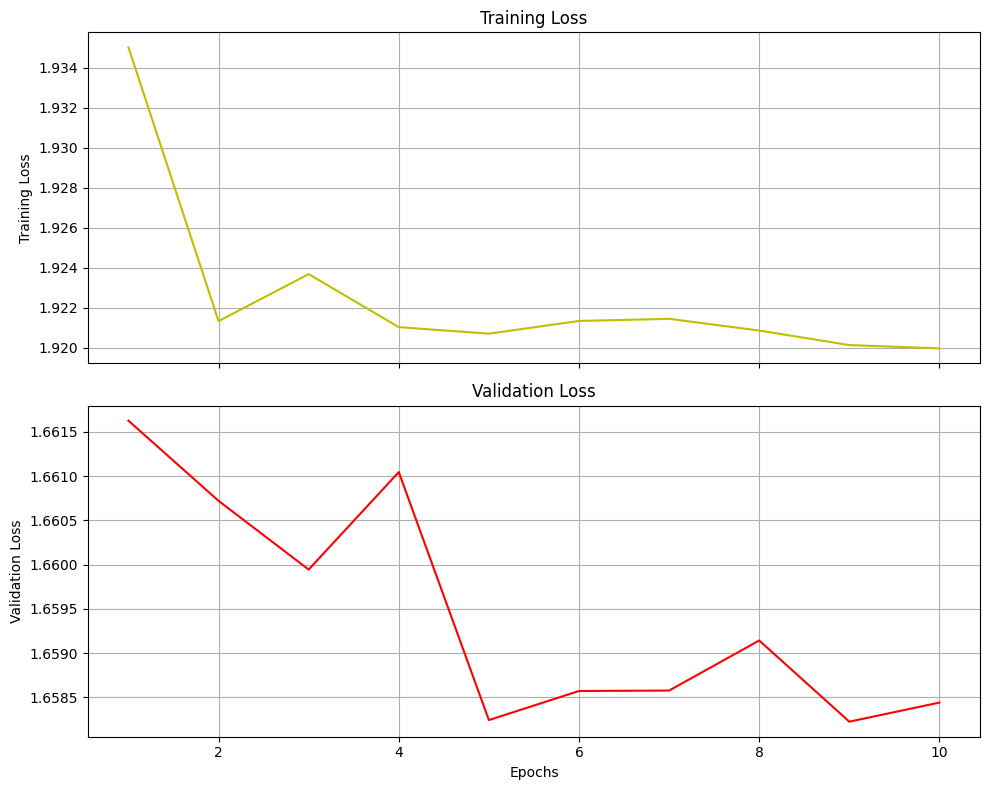

In [ ]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top plot: Training
ax1.plot(epochs, train_losses, "y-")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

# Bottom plot: Validation
ax2.plot(epochs, val_losses, "r-")
ax2.set_ylabel("Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_title("Validation Loss")
ax2.grid(True)

plt.tight_layout()
plt.show()

### T6

When does the model start to overfit?

**Ans:** At Epoch 5 since the validation loss start to increasing.

### T7

Plot the learning rate as a function of the epochs.

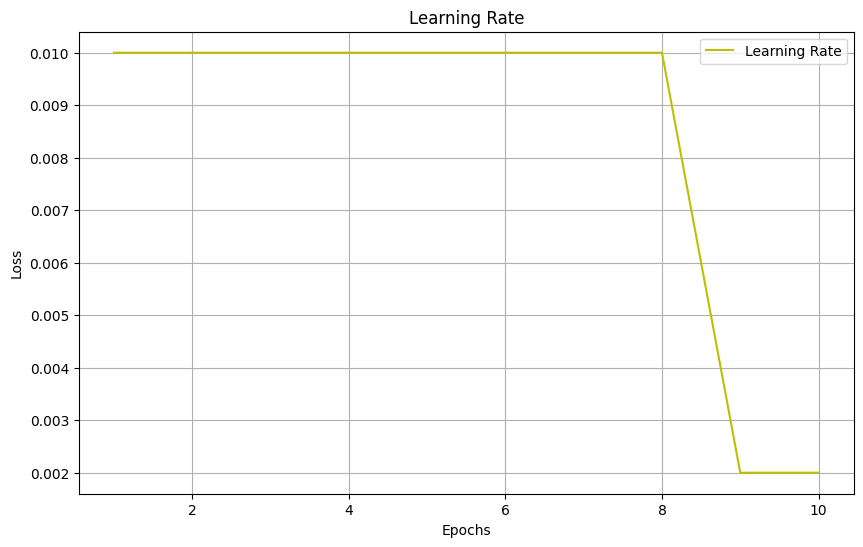

In [24]:
plt.figure(figsize=(10,6))
plt.plot(epochs, learning_rates, "y", label="Learning Rate")
plt.title("Learning Rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### T8

What makes the learning rate change?
(hint: try to understand the scheduler [ReduceLROnPlateau](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html))


**Ans:** The ReduceLROnPlateau will reduct Learning Rate when metric, which in this context is the validation loss, stop decreasing.

# Load Model

Use the code snippet below to load the model you just trained

In [15]:
checkpoint = torch.load('model_ff.pth.tar')
model_ff = FeedForwardNN(hidden_size=config['hidden_size']) # Create model object
model_ff.load_state_dict(checkpoint["model"])  # Load weights
model_ff = model_ff.to(device)
print(f"Loaded epoch {checkpoint['epoch']} model")

Loaded epoch 8 model


# A more complex scheduling

The scheduler can be very complicated and you can write your own heuristic for it.

### T9

Implement a custom learning rate scheduler that behaves like the following graph.

You might want to learn how to use [PyTorch's built-in learning rate schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) in order to build your own.

Learning rate should be function of epoch.

![](https://raw.githubusercontent.com/pjumruspun/ComProg2021-Workshop/main/graph.png)

In [15]:
class MyScheduler:
    def __init__(self, optimizer: torch.optim.Optimizer):
        self.optimizer = optimizer

    def step(self, epoch):
        # Slope 1: 0 to 3 (Rising to 0.001)
        if epoch <= 3:
            lr = 0.0001 + (0.0009 * epoch / 3)

        # Slope 2: 3 to 6 (Falling to 0.0005)
        elif epoch <= 6:
            lr = 0.0010 - (0.0005 * (epoch - 3) / 3)

        # Slope 3: 6 to 7 (Rising back to 0.001)
        elif epoch <= 7:
            lr = 0.0005 + (0.0005 * (epoch - 6))

        # Slope 4: 7 to 9 (Falling back to 0.0001)
        else:
            lr = 0.0010 - (0.0009 * (epoch - 7) / 2)

        # Update the optimizer
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr

        return lr

In [16]:
# Now train with your scheduler
train_losses = []
val_losses = []
learning_rates = []

model_ff_custom = FeedForwardNN(hidden_size=config["hidden_size"]).to(device)
optimizer_custom = torch.optim.Adam(
    model_ff_custom.parameters(), lr=0.0
)  # Initialize with 0.0, scheduler will set it
my_scheduler = MyScheduler(optimizer_custom)

In [ ]:


# Start wandb run
wandb.init(
    project="precipitation-nowcasting-2026",
    config=config,
    name="T9_Custom_Scheduler" # Name the run to distinguish it
)

# Start training loop
for epoch in range(config["epochs"]):  # loop over the dataset multiple times

    # 1. Update Learning Rate at the start of the epoch
    current_lr = my_scheduler.step(epoch)
    learning_rates.append(current_lr)

    # 2. Training
    model_ff_custom.train() # Set to train mode
    train_loss_list = [] # List to store batch losses

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr:.6f}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer_custom.zero_grad()

        # Predict
        y_pred = model_ff_custom(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer_custom.step()

        # Log batch loss
        train_loss_list.append(loss.item())

    # Calculate average training loss for the epoch
    avg_train_loss = np.mean(train_loss_list)
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # 3. Validation
    model_ff_custom.eval() # Set to eval mode
    val_loss_list = []
    
    with torch.no_grad():  # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_ff_custom(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log batch loss
            val_loss_list.append(loss.item())

        # Calculate average validation loss for the epoch
        avg_val_loss = np.mean(val_loss_list)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")
        
        # Note: We do NOT step the scheduler here because it's epoch-based, handled at start

        # Save checkpoint if val_loss is the best we got
        best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
        if avg_val_loss < best_val_loss:
            state = {
                "epoch": epoch,
                "model": model_ff_custom.state_dict(),
                "optimizer": optimizer_custom.state_dict(),
                "my_scheduler": "CustomT9",
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
            }

            print(f"Saving new best model... (Loss: {avg_val_loss:.4f})")
            torch.save(state, "model_ff_custom.pth.tar")

    # 4. Log to WandB
    wandb.log(
        {
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr": current_lr,
        }
    )

wandb.finish()
print("Finished Training")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: chatrin (chatrin-chulalongkorn-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training epoch 1...
Current LR: 0.000100


  0%|          | 0/1121 [00:00<?, ?it/s]

Epoch 1 train loss: 1.9194
Validating epoch 1


...

Epoch 10 train loss: 1.9171
Validating epoch 10


  0%|          | 0/454 [00:00<?, ?it/s]

Epoch 10 val loss: 1.6556


lr,▁▃▆█▇▅▄█▄▁
train_loss,█▆▅▆▅▄▃▄▂▁
val_loss,▇█▅▄▂▂▂▁▃▁
lr,0.0001
train_loss,1.9171
val_loss,1.65556


Finished Training


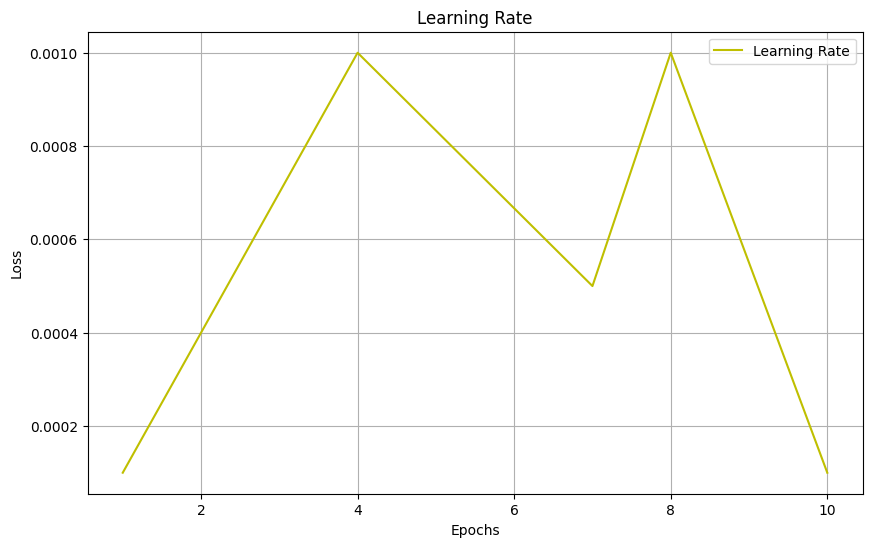

In [21]:

epochs = [i for i in range(1,len(learning_rates) + 1)]
plt.figure(figsize=(10, 6))
plt.plot(epochs, learning_rates, "y", label="Learning Rate")
plt.title("Learning Rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
checkpoint_custom = torch.load("model_ff_custom.pth.tar", weights_only=False)
loaded_custom_model = FeedForwardNN(hidden_size=config["hidden_size"])  # Create model object
loaded_custom_model.load_state_dict(checkpoint["model"])  # Load weights
print(f"Loaded epoch {checkpoint['epoch']} model")

Loaded epoch 8 model


# [Optional] Wandb #

You should now have a project in wandb with the name `precipitation-nowcasting`, which you should see the latest run you just finished inside the project. If you look into the run, you should be able to see plots of learning rate, train loss, val loss in the `Charts` section. Below it should be `Gradients` and `Parameters` section.

# Wandb Observation #

### OT1

Write your own interpretation of the logs from this example. A simple sentence or two for each section is sufficient.

**Your answer:**

# Evaluation

In [17]:
################################################################################
# T10:                                                                     #
# Write a function to evaluate your model. Your function must predicts         #
# using the input model and return mean square error of the model.             #
#                                                                              #
# Hint: Read how to use PyTorch's MSE Loss                                     #
# https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
def evaluate(data_loader, model):
    """
    Evaluate model on validation data given by data_loader
    """
    model.eval()
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item()
            
    return total_loss / len(data_loader)

In [18]:
# We will use majority rule as a baseline.
def majority_baseline(label_set):
    unique, counts = np.unique(label_set, return_counts=True)
    majority = unique[np.argmax(counts)]
    baseline = 0
    label_set = label_set.reshape(-1,1)
    for r in label_set:
        baseline += (majority - r) ** 2 / len(label_set)
    return baseline

In [24]:
print('baseline')
print('train', majority_baseline(y_train))
print('validate', majority_baseline(y_val))

baseline
train [1.94397725]
validate [1.6746546]


In [33]:
print('FF-model')
print('train', evaluate(train_loader, model_ff))
print('validate', evaluate(val_loader, model_ff))

FF-model
train 1.9202160173354141
validate 1.6582261308543549


# Dropout #

You might notice that the 3-layered feedforward does not use dropout at all. Now, try adding dropout (dropout rate of 20%) to the model, run, and report the result again.

To access PyTorch's dropout, use `nn.Dropout`. Read more about PyTorch's built-in Dropout layer [here](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

In [19]:
################################################################################
# T11:                                                                     #
# Write a feedforward model with dropout                                       #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
class FeedForwardNNDropOut(nn.Module):
    def __init__(self, hidden_size=200):
        super(FeedForwardNNDropOut, self).__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        hd1 = self.dropout(F.relu(self.ff1(x)))
        hd2 = self.dropout(F.relu(self.ff2(hd1)))
        y = self.dropout(F.relu(self.ff3(hd2)))
        y = self.out(y)
        return y.reshape(-1, 1)

In [22]:
################################################################################
# T12:                                                                     #
# Complete the code to train your dropout model                                #
################################################################################
print('start training ff dropout')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
train_losses = []
val_losses = []
learning_rates = []

model_ff_dropout = FeedForwardNNDropOut(hidden_size=config["hidden_size"])
model_ff_dropout = model_ff_dropout.to(device)
optimizer = torch.optim.Adam(model_ff_dropout.parameters(), lr=config["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    "min",
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
    min_lr=config["scheduler_min_lr"],
)
wandb.init(
    project="precipitation-nowcasting-2026",
    config=config,
    name="T12_Dropout_Model",  # Name the run to distinguish it
)

# Start training loop
for epoch in range(config["epochs"]):  # loop over the dataset multiple times

    # 1. Update Learning Rate at the start of the epoch
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # 2. Training
    model_ff_dropout.train()  # Set to train mode
    train_loss_list = []  # List to store batch losses

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr:.6f}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer.zero_grad()

        # Predict
        y_pred = model_ff_dropout(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer.step()

        # Log batch loss
        train_loss_list.append(loss.item())

    # Calculate average training loss for the epoch
    avg_train_loss = np.mean(train_loss_list)
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # 3. Validation
    model_ff_dropout.eval()  # Set to eval mode
    val_loss_list = []

    with torch.no_grad():  # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_ff_dropout(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log batch loss
            val_loss_list.append(loss.item())

        # Calculate average validation loss for the epoch
        avg_val_loss = np.mean(val_loss_list)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")

        scheduler.step(avg_val_loss)
        # Save checkpoint if val_loss is the best we got
        best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
        if avg_val_loss < best_val_loss:
            state = {
                "epoch": epoch,
                "model": model_ff_dropout.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
            }

            print(f"Saving new best model... (Loss: {avg_val_loss:.4f})")
            torch.save(state, "model_ff_dropout.pth.tar")

    # 4. Log to WandB
    wandb.log(
        {
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr": current_lr,
        }
    )

wandb.finish()
print("Finished Training")

start training ff dropout


Training epoch 1...
Current LR: 0.010000


  0%|          | 0/1121 [00:00<?, ?it/s]

Epoch 1 train loss: 1.9273
Validating epoch 1


  0%|          | 0/454 [00:00<?, ?it/s]

...

Epoch 10 train loss: 1.9233
Validating epoch 10


  0%|          | 0/454 [00:00<?, ?it/s]

Epoch 10 val loss: 1.6608


lr,███████▁▁▁
train_loss,█▁▃▂▂▂▃▃▃▂
val_loss,▂▆█▁▃▄▅▄▅▄
lr,0.002
train_loss,1.92327
val_loss,1.66084


Finished Training


### T13

Plot the losses and MSE of the training and validation as before. Evaluate the dropout model's performance

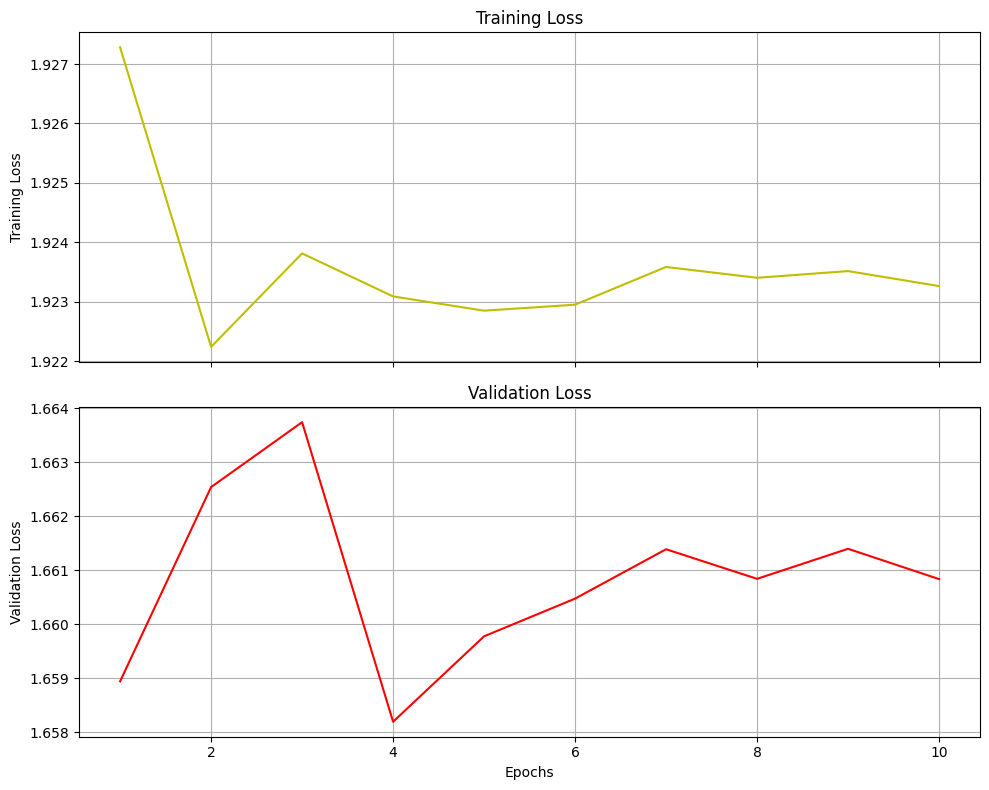

In [23]:
# Plot here
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top plot: Training
ax1.plot(epochs, train_losses, "y-")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

# Bottom plot: Validation
ax2.plot(epochs, val_losses, "r-")
ax2.set_ylabel("Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_title("Validation Loss")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [24]:
# Evaluate
print("FF_NN_Dropout_Model")
print("train", evaluate(train_loader, model_ff_dropout))
print("train", evaluate(val_loader, model_ff_dropout))

FF_NN_Dropout_Model
train 1.923506092057496
train 1.6608393325630395


# Convolution Neural Networks
Now let's try to incorporate the grid sturcture to your model. Instead of passing in vectors, we are going to pass in the 5x5 grid into the model (5lat x 5long x 3channel). You are going to implement you own 2d-convolution neural networks with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
Conv2DNN                                 --                        --
├─Conv2d: 1-1                            [1024, 200, 3, 3]         5,600
├─Linear: 1-2                            [1024, 200]               360,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
==========================================================================================
Total params: 406,201
Trainable params: 406,201
Non-trainable params: 0
```
These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         

Hint: You should read PyTorch documentation to see the list of available layers and options you can use.                         

In [20]:
################################################################################
# T14:                                                                     #
# Complete the code for preparing data for training CNN                        #
# Input for CNN should not have time step.                                     #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
class RainfallDatasetCNN(Dataset):
    def __init__(self, x, y, normalizer):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)
        self.normalizer = normalizer
    
    def __getitem__(self, index):
        x = self.x[index]
        x = self.normalizer.transform(x.reshape(1, -1))
        x = x.reshape(3, 5, 5)
        y = self.y[index]
        return x, y
    
    def __len__(self):
        return self.x.shape[0]

In [21]:
def preprocess_for_cnn(x, y):
    x_cnn = x.reshape(-1, 5, 5, 3)
    x_cnn = np.transpose(x_cnn, (0, 3, 1, 2))

    y_cnn = y.reshape(-1, 1)
    return x_cnn, y_cnn

In [22]:
x_train_cnn, y_train_cnn = preprocess_for_cnn(x_train, y_train)
x_val_cnn, y_val_cnn = preprocess_for_cnn(x_val, y_val)
x_test_cnn, y_test_cnn = preprocess_for_cnn(x_test, y_test)

normalizer = normalizer_std(
    x_train_ff
)
train_dataset_cnn = RainfallDatasetCNN(
    x_train_cnn, y_train_cnn, normalizer
)
val_dataset_cnn = RainfallDatasetCNN(x_val_cnn, y_val_cnn, normalizer)
test_dataset_cnn = RainfallDatasetCNN(x_test_cnn, y_test_cnn, normalizer)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=1024, shuffle=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=1024, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=1024, shuffle=False)

In [23]:
################################################################################
# T15:                                                                     #
# Write a PyTorch convolutional neural network model.                          #
# You might want to use the layer torch.flatten somewhere                      #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
class Conv2DNN(nn.Module):
    def __init__(self, hidden_size=200):
        super(Conv2DNN, self).__init__()
        self.cn1 = nn.Conv2d(3, hidden_size, kernel_size=3)
        self.fc1 = nn.Linear(hidden_size * 3 * 3, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        cn = F.relu(self.cn1(x))
        x_flat = torch.flatten(cn,1)
        hd1 = F.relu(self.fc1(x_flat))
        x = F.relu(self.fc2(hd1))
        y = self.out(x)
        return y.reshape(-1, 1)

In [24]:
# Hyperparameters and other configs
config_cnn = {
    "architecture": "cnn",
    "lr": 0.01,
    "hidden_size": 200,
    "scheduler_factor": 0.2,
    "scheduler_patience": 2,
    "scheduler_min_lr": 1e-4,
    "epochs": 10,
}

model_cnn = Conv2DNN(hidden_size=config_cnn["hidden_size"]).to(device)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=config_cnn["lr"])
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn,
    "min",
    factor=config_cnn["scheduler_factor"],
    patience=config_cnn["scheduler_patience"],
    min_lr=config_cnn["scheduler_min_lr"],
)

In [48]:
################################################################################
# T16:                                                                     #
# Complete the code to train your cnn model                                    #
################################################################################
print('start training conv2d')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
train_losses = []
val_losses = []
learning_rates = []


# Start wandb run
wandb.init(
    project="precipitation-nowcasting-2026",
    config=config_cnn,
    name="T16_CNN_Model",
    reinit=True,
)
# Start training loop
for epoch in range(config_cnn["epochs"]):  # loop over the dataset multiple times

    # 1. Update Learning Rate at the start of the epoch
    current_lr = optimizer_cnn.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # 2. Training
    model_cnn.train()  # Set to train mode
    train_loss_list = []  # List to store batch losses

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr:.6f}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader_cnn)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer_cnn.zero_grad()

        # Predict
        y_pred = model_cnn(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer_cnn.step()

        # Log batch loss
        train_loss_list.append(loss.item())

    # Calculate average training loss for the epoch
    avg_train_loss = np.mean(train_loss_list)
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # 3. Validation
    model_cnn.eval()  # Set to eval mode
    val_loss_list = []

    with torch.no_grad():  # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        for i, (inputs, y_true) in enumerate(tqdm(val_loader_cnn)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_cnn(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log batch loss
            val_loss_list.append(loss.item())

        # Calculate average validation loss for the epoch
        avg_val_loss = np.mean(val_loss_list)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")

        scheduler_cnn.step(avg_val_loss)
        # Save checkpoint if val_loss is the best we got
        best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
        if avg_val_loss < best_val_loss:
            state = {
                "epoch": epoch,
                "model": model_cnn.state_dict(),
                "optimizer": optimizer_cnn.state_dict(),
                "scheduler": scheduler_cnn.state_dict(),
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
            }

            print(f"Saving new best model... (Loss: {avg_val_loss:.4f})")
            torch.save(state, "model_cnn.pth.tar")

    # 4. Log to WandB
    wandb.log(
        {
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr": current_lr,
        }
    )

wandb.finish()
print("Finished Training")

start training conv2d


Training epoch 1...
Current LR: 0.010000


  0%|          | 0/1121 [00:00<?, ?it/s]

Epoch 1 train loss: 2.7296
Validating epoch 1


  0%|          | 0/454 [00:00<?, ?it/s]

...

Epoch 10 train loss: 1.9203
Validating epoch 10


  0%|          | 0/454 [00:00<?, ?it/s]

Epoch 10 val loss: 1.6587


lr,▁▁▁▁▁▁▁▁▁▁
train_loss,█▁▁▁▁▁▁▁▁▁
val_loss,▃▄▃▁▆▆▃▄▅█
lr,0.01
train_loss,1.92033
val_loss,1.65874


Finished Training


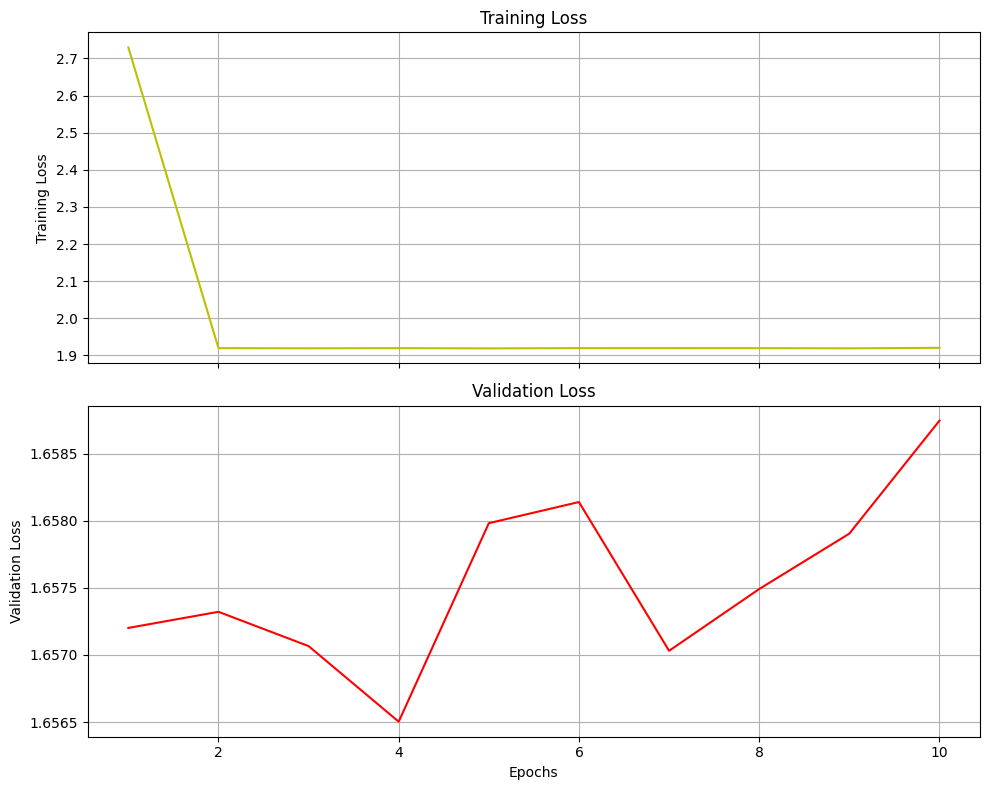

In [49]:
# Plot losses
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top plot: Training
ax1.plot(epochs, train_losses, "y-")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

# Bottom plot: Validation
ax2.plot(epochs, val_losses, "r-")
ax2.set_ylabel("Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_title("Validation Loss")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [50]:
# Evaluate
print("FF-model")
print("train", evaluate(train_loader_cnn, model_cnn))
print("validate", evaluate(val_loader_cnn, model_cnn))

FF-model
train 1.9197376234976975
validate 1.658744670824037


# [Optional] Gated Recurrent Units

Now, you want to add time steps into your model. Recall the original data has 5 time steps per item. You are going to pass in a data of the form 5 timesteps x 75data. This can be done using a GRU layer. Implement you own GRU network with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
GRUModel                                 --                        --
├─GRU: 1-1                               [1024, 5, 200]            166,200
├─Linear: 1-2                            [1024, 5, 200]            40,200
├─Linear: 1-3                            [1024, 5, 1]              201
==========================================================================================
Total params: 206,601
Trainable params: 206,601
Non-trainable params: 0
```


These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         
The result should be better than the feedforward model and at least on par with your CNN model.    

Do consult PyTorch documentation on how to use [GRUs](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html).


In [ ]:
################################################################################
# OT2:                                                                     #
# Complete the code for preparing data for training GRU                        #
# GRU's input should has 3 dimensions.                                         #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
################################################################################
# OT3:                                                                      #
# Write a PyTorch GRU model.                                                   #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
################################################################################
# OT4:                                                                      #
# Complete the code to train your gru model                                    #
################################################################################
print('start training gru')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
# Plot


In [ ]:
# Evaluate


# Transformer

Welcome to the beginning of the real world! The aboved models are not usually used in practice due to its limited capability. Transformers are generally used by computer vision, natural language processing, and speech processing (almost every big AI fields).



In our dataloader, we will add the output of this timestep (the number of precipitation) as an auxiliary input to predict the next timestep. Thus, input for the model should be [#batch_size, 5, 76] (5 timesteps and the number 76 comes from (3x5x5)+1) and the output for the model should be [#batch_size, 1] which would be the next timestep we want to predict. Additionally, we will mask the input at the dataloader to the attenttion from observing future values. Suppose that we want to predict timestep 3, we will mask the timestep 3, 4 and 5 in our input by setting it to zeros, and we will predict the timestep 3.

In order to get a score on this TODO, students need to implement a dataloader that mask the input correctly.

(Note, in this homework, we ask you to mask the input which is simple to do. In practice, people prefer to mask the attention mask instead. This makes decoder-only architectures more parallelizable.)

In [25]:
################################################################################
# T17:                                                                        #
# Complete the code for preparing data for training Transformer                #
# Transformer's input should has 3 dimensions.                                 #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
class RainfallDatasetTransformer(Dataset):
    def __init__(self, x, y, normalizer):
        self.x = x.astype(np.float32) # Shape :[n,5,5,5,3]
        self.y = y.astype(np.float32) # Shape:[n, 5]
        self.normalizer = normalizer

    def __getitem__(self, index):
        x = self.x[index] #[5,5,5,3]
        y = self.y[index] #[5]

        x_flat = x.reshape(5, -1) #flatten spatial [5,5,5,3] -> [5,75]

        x_normalized = self.normalizer.transform(x_flat)  # Normalize

        # Create Auxiliary. For timestep t use precapi from step t-1
        prev_precip = np.zeros((5, 1), dtype=np.float32)
        prev_precip[1:] = y[:-1].reshape(-1, 1) # Shift y by 1

        x_with_precip = np.concatenate([x_normalized, prev_precip], axis=1) # Concatenate to [5, 76]

        target_timestep = np.random.randint(0, 5)

        x_masked = x_with_precip.copy()
        if target_timestep < 4:
            x_masked[target_timestep + 1:] = 0
        return (
            torch.from_numpy(x_masked),
            torch.tensor(y[target_timestep], dtype=torch.float32).unsqueeze(0),
            torch.tensor(target_timestep)
        )

    def __len__(self):
        return self.x.shape[0]

In [26]:
# Create normalizer
normalizer = normalizer_std(x_train_ff)  # Reuse from previous section

# Create datasets
train_dataset_tf = RainfallDatasetTransformer(x_train, y_train, normalizer)
val_dataset_tf = RainfallDatasetTransformer(x_val, y_val, normalizer)

# Create dataloaders
train_loader_tf = DataLoader(
    train_dataset_tf, batch_size=1024, shuffle=True, pin_memory=True
)
val_loader_tf = DataLoader(
    val_dataset_tf, batch_size=1024, shuffle=False, pin_memory=True
)


In this task, we will implement one encoder layer of Transformer and add the linear layer to make a regression prediction. For the simplicity of the model, we will change the multi-head attention to QKV self-attention (single-head). As a result, our model should look like the diagram below. Since the layer self-attention is not availble in torch, students have to implement it themselves. In Add & Norm layer, students have to do the addition before normalizing. In Layer Normalization, we will normalize across both timesteps and features.

If you feel loss in this part of the assignment, watching this [video](https://www.youtube.com/watch?v=kCc8FmEb1nY) might help.

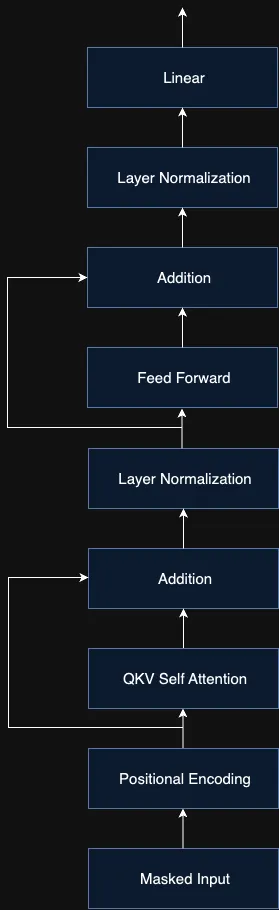

```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
TransformerModel                         [1024, 1]                 --
├─PositionalEncoding: 1-1                [1024, 5, 76]             --
│    └─Dropout: 2-1                      [1024, 5, 76]             --
├─SelfAttention: 1-2                     [1024, 5, 76]             --
│    └─Linear: 2-2                       [1024, 5, 76]             5,852
│    └─Linear: 2-3                       [1024, 5, 76]             5,852
│    └─Linear: 2-4                       [1024, 5, 76]             5,852
│    └─Softmax: 2-5                      [1024, 5, 5]              --
├─LayerNorm: 1-3                         [1024, 5, 76]             760
├─Linear: 1-4                            [1024, 5, 76]             5,852
├─LayerNorm: 1-5                         [1024, 5, 76]             760
├─Linear: 1-6                            [1024, 1]                 381
==========================================================================================
Total params: 25,309
Trainable params: 25,309
Non-trainable params: 0
Total mult-adds (M): 25.92
==========================================================================================
Input size (MB): 1.56
Forward/backward pass size (MB): 18.69
Params size (MB): 0.10
Estimated Total Size (MB): 20.34
==========================================================================================
```

In [27]:
################################################################################
# T18                                                                         #
# Write a PyTorch PositionalEncoding Layer.                                    #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class PositionalEncoding(nn.Module):
    def __init__(self, seq_len, emb_dim, dropout=0.2):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # create positional encode matrix
        pe = torch.zeros(seq_len, emb_dim)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)

        # div_term for sine and cosine
        div_term = torch.exp(torch.arange(0, emb_dim, 2).float() * (-np.log(10000.0) / emb_dim))

        # Apply sine to even indices, cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        if emb_dim % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])

        pe = pe.unsqueeze(0) # Add batch dimesion: [1, seq_len, emb_dim]
        self.register_buffer('pe', pe) # Register as buffer (not a parameter, but part of state)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [28]:
################################################################################
# T19                                                                         #
# Write a PyTorch Transformer model.                                           #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class SelfAttention(nn.Module):

    def __init__(self, input_dim):
        super(SelfAttention, self).__init__()
        self.input_dim = input_dim

        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        # Generate Q, K, V
        Q = self.query(x)  # [batch, seq_len, input_dim]
        K = self.key(x)  # [batch, seq_len, input_dim]
        V = self.value(x)  # [batch, seq_len, input_dim]

        # Compute attention scores
        # Q @ K^T / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1))  # [batch, seq_len, seq_len]
        scores = scores / np.sqrt(self.input_dim)

        # Apply softmax to get attention weights
        attention_weights = self.softmax(scores)  # [batch, seq_len, seq_len]

        # Apply attention to values
        output = torch.matmul(attention_weights, V)  # [batch, seq_len, input_dim]

        return output

class TransformerModel(nn.Module):
    def __init__(self, seq_len, input_dim, dropout):
        super(TransformerModel, self).__init__()

        # Positional encoding
        self.pe = PositionalEncoding(seq_len, input_dim, dropout)
        # Self-attention layer
        self.sa = SelfAttention(input_dim)

        # Layer normalization layers
        self.norm1 = nn.LayerNorm([seq_len, input_dim])
        self.norm2 = nn.LayerNorm([seq_len, input_dim])

        # Feed-forward network
        self.ff = nn.Linear(input_dim, input_dim)

        # Output layer
        self.out = nn.Linear(input_dim, 1)

    def forward(self, x, target_timestep):
        # x shape: [batch, seq_len, input_dim]

        # 1. positional encoding
        x = self.pe(x)

        # 2. QKV Self-attention
        attn_output = self.sa(x)

        # 3. Add & Norm
        x = x + attn_output
        x = self.norm1(x)

        # 4. Feed-forward
        ff_output = self.ff(x)

        # 5. Add & Norm
        x = x + ff_output
        x = self.norm2(x)

        # Select the specific timestep for each sample in batch
        batch_indices = torch.arange(x.size(0), device=x.device)
        x = x[batch_indices, target_timestep]  # [batch, 76]

        output = self.out(x)  # [batch, 1]
        return output

In [29]:
# Training configuration
config_tf = {
    "architecture": "transformer",
    "lr": 0.001,
    "epochs": 10,
    "scheduler_factor": 0.5,
    "scheduler_patience": 3,
    "scheduler_min_lr": 1e-5,
}

# Initialize model
model_tf = TransformerModel(input_dim=76, seq_len=5, dropout=0.2).to(device)
optimizer_tf = torch.optim.Adam(model_tf.parameters(), lr=config_tf["lr"])
scheduler_tf = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tf,
    "min",
    factor=config_tf["scheduler_factor"],
    patience=config_tf["scheduler_patience"],
    min_lr=config_tf["scheduler_min_lr"],
)

In [ ]:
################################################################################
# T20                                                                         #
# Complete the code to train your Transformer model                                    #
################################################################################
print('start training transformer')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

# Loss function
loss_fn = nn.MSELoss()

# Start wandb
wandb.init(
    project="precipitation-nowcasting-2026", config=config_tf, name="Transformer"
)

# Training loop
train_losses = []
val_losses = []
learning_rates = []

try:
    for epoch in range(config_tf["epochs"]):
        # Training
        model_tf.train()
        train_loss_list = []
        current_lr = optimizer_tf.param_groups[0]["lr"]
        learning_rates.append(current_lr)

        print(f"Epoch {epoch+1}/{config_tf['epochs']}")
        print(f"Learning Rate: {current_lr:.6f}")

        for inputs, targets, target_timestep in tqdm(train_loader_tf, desc="Training"):
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer_tf.zero_grad()
            outputs = model_tf(inputs, target_timestep)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer_tf.step()

            train_loss_list.append(loss.item())

        avg_train_loss = np.mean(train_loss_list)
        train_losses.append(avg_train_loss)
        print(f"Train Loss: {avg_train_loss:.4f}")

        # Validation
        model_tf.eval()
        val_loss_list = []

        with torch.no_grad():
            for inputs, targets, target_timestep in tqdm(val_loader_tf, desc="Validation"):
                inputs = inputs.to(device)
                targets = targets.to(device)

                outputs = model_tf(inputs, target_timestep)

                loss = loss_fn(outputs, targets)
                val_loss_list.append(loss.item())

        avg_val_loss = np.mean(val_loss_list)
        val_losses.append(avg_val_loss)
        print(f"Val Loss: {avg_val_loss:.4f}\n")

        # Scheduler step
        scheduler_tf.step(avg_val_loss)

        # Save best model
        if epoch == 0 or avg_val_loss < min(val_losses[:-1]):
            torch.save(
                {
                    "epoch": epoch,
                    "model": model_tf.state_dict(),
                    "optimizer": optimizer_tf.state_dict(),
                    "scheduler": scheduler_tf.state_dict(),
                    "train_loss": avg_train_loss,
                    "val_loss": avg_val_loss,
                },
                "model_transformer.pth.tar",
            )
            print("✓ Saved new best model")

        # Log to wandb
        wandb.log(
            {
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "lr": current_lr,
            }
        )
except KeyboardInterrupt:
    print("\nTraining interrupted by user. Saving state and closing wandb...")
finally:
    # This runs no matter what (normal finish or manual stop)
    wandb.finish()
    print("Finished Training Transformer")

start training transformer


Epoch 1/10
Learning Rate: 0.001000


Training:   0%|          | 0/225 [00:00<?, ?it/s]

Train Loss: 1.7774


Validation:   0%|          | 0/91 [00:00<?, ?it/s]

...

Train Loss: 1.9775


Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Val Loss: 1.4470



lr,▁▁▁▁▁▁▁▁▁▁
train_loss,▃▂▂▆▅▂▁▄▄█
val_loss,█▃▄▅▂█▁▆▆▃
lr,0.001
train_loss,1.97747
val_loss,1.44705


Finished Training Transformer


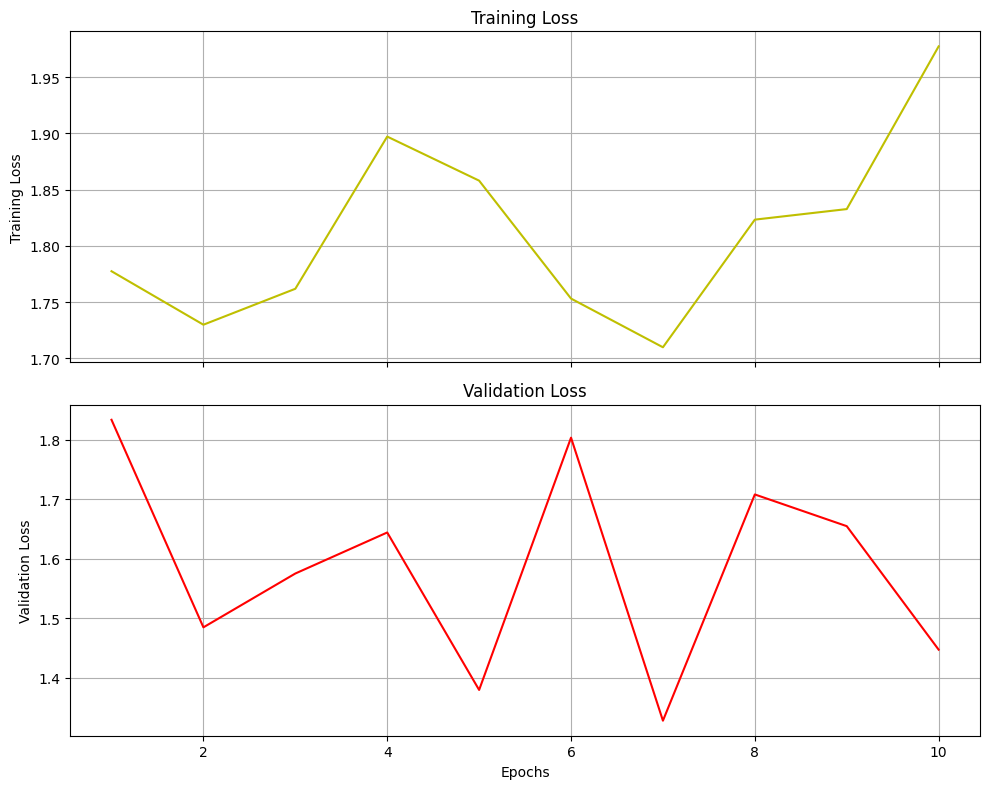

In [33]:
# Plot
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top plot: Training
ax1.plot(epochs, train_losses, "y-")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

# Bottom plot: Validation
ax2.plot(epochs, val_losses, "r-")
ax2.set_ylabel("Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_title("Validation Loss")
ax2.grid(True)

plt.tight_layout()
plt.show()

If you implement it correctly, you should evaluate the model in the test dataset and the score should be better than the aboved models.

In [30]:
def evaluate_transformer(data_loader, model):
    """
    Evaluate transformer model on validation/test data given by data_loader.
    Args:
        data_loader: DataLoader that returns (inputs, targets, target_timestep)
        model: Transformer model to evaluate
    Returns:
        float: Mean squared error loss
    """
    model.eval()
    loss_fn = nn.MSELoss()
    total_loss = 0.0

    with torch.no_grad():
        for inputs, targets, target_timestep in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs, target_timestep)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item()

    return total_loss / len(data_loader)

In [36]:
# Evaluate
print("Tranformer")
print("train", evaluate_transformer(train_loader_tf, model_tf))
print("validate", evaluate_transformer(val_loader_tf, model_tf))

Tranformer
train 1.654751859638426
validate 1.600861530617944


# Final Section
# PyTorch playground

Now, train the best model you can do for this task. You can use any model structure and function available.    
Remember that trainig time increases with the complexity of the model. You might find printing computation graphs helpful in debugging complicated models.    
Your model should be better than your CNN or Transformer model in the previous sections.

Some ideas:

- Tune the hyperparameters
- Adding dropouts
- Combining different types of models

You should tune your model on training and validation set.    
**The test set should be used only for the last evaluation.**

In [ ]:
# Data preparation for the best model.

BATCH_SIZE = 1024

train_loader_final = DataLoader(
    RainfallDatasetTransformer(x_train, y_train, normalizer),
    batch_size=BATCH_SIZE, shuffle=True, pin_memory=True,
)
val_loader_final = DataLoader(
    RainfallDatasetTransformer(x_val, y_val, normalizer),
    batch_size=BATCH_SIZE, shuffle=False, pin_memory=True,
)

sample_x, sample_y, sample_t = next(iter(train_loader_final))
print(f"Feature shape per batch: {sample_x.shape}  (expected [1024, 5, 76])")
print(f"Train batches: {len(train_loader_final)} | Val batches: {len(val_loader_final)}")


Feature shape per batch: torch.Size([1024, 5, 76])  (expected [1024, 5, 76])
Train batches: 225 | Val batches: 91


In [41]:
import wandb

In [ ]:
################################################################################
# T21                                                                          #
# Write a function that returns your best PyTorch model.                       #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

BEST_INPUT_DIM = 76 

class BestTransformerModel(nn.Module):
    """
    Improved Transformer over the baseline (TransformerModel).
    This model keeps the same global LayerNorm and adds:
      - 4-head nn.MultiheadAttention — richer attention patterns
      - FF: Linear(76→304) → ReLU → Linear(304→76) — non-linear transformation
    """
    def __init__(self, seq_len=5, input_dim=BEST_INPUT_DIM, nhead=4, dropout=0.1):
        super(BestTransformerModel, self).__init__()
        assert input_dim % nhead == 0, (
            f"input_dim ({input_dim}) must be divisible by nhead ({nhead})"
        )

        # Positional encoding (reuse existing PositionalEncoding class)
        self.pe = PositionalEncoding(seq_len, input_dim, dropout)

        # 4-head multi-head attention (baseline had 1-head)
        self.mha = nn.MultiheadAttention(
            embed_dim=input_dim, num_heads=nhead,
            dropout=dropout, batch_first=True,
        )

        # Same global LayerNorm as baseline: normalises over [seq_len, input_dim]
        self.norm1 = nn.LayerNorm([seq_len, input_dim])
        self.norm2 = nn.LayerNorm([seq_len, input_dim])

        # Improved FF: Linear → ReLU → Linear (baseline had just one Linear, no activation)
        self.ff1 = nn.Linear(input_dim, input_dim * 4)   # 76 → 304
        self.ff2 = nn.Linear(input_dim * 4, input_dim)   # 304 → 76
        self.ff_dropout = nn.Dropout(dropout)

        # Output head (same as baseline)
        self.out = nn.Linear(input_dim, 1)

    def forward(self, x, target_timestep):
        # x: [batch, seq_len, input_dim]

        # 1. Positional encoding
        x = self.pe(x)

        # 2. Multi-head self-attention
        attn_out, _ = self.mha(x, x, x)

        # 3. Add & global Norm
        x = x + attn_out
        x = self.norm1(x)

        # 4. Feed-forward with activation (unlike baseline which has no activation)
        ff_out = self.ff_dropout(F.relu(self.ff1(x)))
        ff_out = self.ff2(ff_out)

        # 5. Add & global Norm
        x = x + ff_out
        x = self.norm2(x)

        # 6. Select target timestep
        batch_indices = torch.arange(x.size(0), device=x.device)
        if isinstance(target_timestep, int):
            x = x[:, target_timestep, :]
        else:
            x = x[batch_indices, target_timestep, :]

        return self.out(x)  # [batch, 1]


# Verify
model_best = BestTransformerModel().to(device)
num_params = sum(p.numel() for p in model_best.parameters() if p.requires_grad)
normal_tf_params = sum(p.numel() for p in model_tf.parameters() if p.requires_grad)
print(f"BestTransformerModel  — Trainable parameters: {num_params:,}")
print(f"Normal TransformerModel — Trainable parameters: {normal_tf_params:,}")
print(model_best)


BestTransformerModel  — Trainable parameters: 71,593
Normal TransformerModel — Trainable parameters: 25,005
BestTransformerModel(
  (pe): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=76, out_features=76, bias=True)
  )
  (norm1): LayerNorm((5, 76), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((5, 76), eps=1e-05, elementwise_affine=True)
  (ff1): Linear(in_features=76, out_features=304, bias=True)
  (ff2): Linear(in_features=304, out_features=76, bias=True)
  (ff_dropout): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=76, out_features=1, bias=True)
)


In [50]:
################################################################################
# T22                                                                          #
# Complete the code to train your best model                                   #
################################################################################
print('start training the best model')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
import copy

config_best = {
    "architecture": "BestTransformer_v6",
    "input_dim": BEST_INPUT_DIM,   # 76
    "nhead": 4,
    "dropout": 0.1,
    "lr": 0.001,
    "epochs": 20,                  # 2× the baseline (10 epochs) for better convergence
    "scheduler_factor": 0.5,
    "scheduler_patience": 3,
    "scheduler_min_lr": 1e-5,      # same as baseline
    "batch_size": BATCH_SIZE,
}

# Re-initialise model
model_best = BestTransformerModel(
    seq_len=5,
    input_dim=config_best["input_dim"],
    nhead=config_best["nhead"],
    dropout=config_best["dropout"],
).to(device)

optimizer_best = torch.optim.Adam(
    model_best.parameters(),
    lr=config_best["lr"],
)

scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_best, mode="min",
    factor=config_best["scheduler_factor"],
    patience=config_best["scheduler_patience"],
    min_lr=config_best["scheduler_min_lr"],
)

loss_fn = nn.MSELoss()

wandb.init(
    project="precipitation-nowcasting-2026",
    config=config_best,
    name="BestTransformer_v6",
    reinit=True,
)

train_losses = []
val_losses = []
learning_rates = []
best_val_loss = float('inf')
best_model_state = None

try:
    print("start training ...")
    for epoch in range(config_best["epochs"]):
        model_best.train()
        train_loss_list = []
        current_lr = optimizer_best.param_groups[0]["lr"]
        learning_rates.append(current_lr)

        print(f"Epoch {epoch+1}/{config_best['epochs']}  LR: {current_lr:.6f}")

        for inputs, targets, target_timestep in tqdm(train_loader_final, desc="Training"):
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer_best.zero_grad()
            outputs = model_best(inputs, target_timestep)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer_best.step()
            train_loss_list.append(loss.item())

        avg_train_loss = np.mean(train_loss_list)
        train_losses.append(avg_train_loss)
        print(f"Train Loss: {avg_train_loss:.4f}")

        model_best.eval()
        val_loss_list = []
        with torch.no_grad():
            for inputs, targets, target_timestep in tqdm(val_loader_final, desc="Validation"):
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model_best(inputs, target_timestep)
                loss = loss_fn(outputs, targets)
                val_loss_list.append(loss.item())

        avg_val_loss = np.mean(val_loss_list)
        val_losses.append(avg_val_loss)
        print(f"Val Loss: {avg_val_loss:.4f}\n")

        scheduler_best.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model_best.state_dict())
            torch.save(
                {
                    "epoch": epoch,
                    "model": best_model_state,
                    "optimizer": optimizer_best.state_dict(),
                    "scheduler": scheduler_best.state_dict(),
                    "train_loss": avg_train_loss,
                    "val_loss": avg_val_loss,
                    "config": config_best,
                },
                "model_best_transformer.pth.tar",
            )
            print(f"✓ Saved new best model (Val Loss: {best_val_loss:.4f})")

        wandb.log({
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr": current_lr,
        })

except KeyboardInterrupt:
    print("\nTraining interrupted.")
except Exception as e:
    print(f"\nAn error occurred: {e}")
finally:
    wandb.finish()
    print("Finished Training Best Transformer")

if best_model_state is not None:
    model_best.load_state_dict(best_model_state)
    print(f"Loaded best model state (Val Loss: {best_val_loss:.4f})")


start training the best model


start training ...
Epoch 1/20  LR: 0.001000


Training:   0%|          | 0/225 [00:00<?, ?it/s]

Train Loss: 1.8238


Validation:   0%|          | 0/91 [00:00<?, ?it/s]

...

Train Loss: 1.6699


Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Val Loss: 1.3767



lr,███████▄▄▄▄▂▂▂▂▁▁▁▁▁
train_loss,▇▆▁▆▆▂▅▄▄▄▇▅▄▃█▃▇▆▃▂
val_loss,▂▅▁▂█▅▄▅▄█▅▁▇▂▄▅▃▅▅▄
lr,6e-05
train_loss,1.6699
val_loss,1.37668


Finished Training Best Transformer
Loaded best model state (Val Loss: 1.1607)


In [51]:
# Evaluate best model on validation and test sets
test_dataset_final = RainfallDatasetTransformer(x_test, y_test, normalizer)
test_loader_final = DataLoader(test_dataset_final, batch_size=1024, shuffle=False)

val_loss_best  = evaluate_transformer(val_loader_final,  model_best)
test_loss_best = evaluate_transformer(test_loader_final, model_best)

print(f"Best Transformer  Val  Loss: {val_loss_best:.4f}")
print(f"Best Transformer  Test Loss: {test_loss_best:.4f}")
print(f"Normal Transformer Test Loss (reference): {evaluate_transformer(DataLoader(RainfallDatasetTransformer(x_test, y_test, normalizer), batch_size=1024, shuffle=False), model_tf):.4f}")


Best Transformer  Val  Loss: 1.3559
Best Transformer  Test Loss: 1.2156
Normal Transformer Test Loss (reference): 1.3907


In [52]:
# Evaluate all models on the test set and compare.

def evaluate_ff(data_loader, model):
    model.eval()
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            total_loss += loss_fn(outputs, targets).item()
    return total_loss / len(data_loader)

def evaluate_cnn(data_loader, model):
    return evaluate_ff(data_loader, model)

def load_checkpoint(path, model):
    ckpt = torch.load(path, weights_only=False)
    model.load_state_dict(ckpt['model'])
    return model

print("=" * 45)
print("  Evaluating all models on the TEST set ...")
print("=" * 45 + "\n")

results = {}

# ── 1. FeedForward NN ────────────────────────────────
test_loader_ff_eval = DataLoader(
    RainfallDatasetFF(x_test_ff, y_test_ff, normalizer),
    batch_size=1024, shuffle=False
)
try:
    m = load_checkpoint("model_ff.pth.tar",
                        FeedForwardNN(hidden_size=config["hidden_size"]).to(device))
    print("Loaded model_ff.pth.tar")
    results["FF NN"] = evaluate_ff(test_loader_ff_eval, m)
except Exception as e:
    print(f"FF NN checkpoint failed ({e}), using in-memory model_ff.")
    results["FF NN"] = evaluate_ff(test_loader_ff_eval, model_ff)
print(f"FF NN Test Loss:            {results['FF NN']:.4f}\n")

# ── 2. FeedForward NN w/ Dropout ────────────────────
try:
    m = load_checkpoint("model_ff_dropout.pth.tar",
                        FeedForwardNNDropOut(hidden_size=config["hidden_size"]).to(device))
    print("Loaded model_ff_dropout.pth.tar")
    results["FF NN Dropout"] = evaluate_ff(test_loader_ff_eval, m)
except Exception as e:
    print(f"FF Dropout checkpoint failed ({e}), using in-memory model_ff_dropout.")
    results["FF NN Dropout"] = evaluate_ff(test_loader_ff_eval, model_ff_dropout)
print(f"FF NN Dropout Test Loss:    {results['FF NN Dropout']:.4f}\n")

# ── 3. CNN ───────────────────────────────────────────
if 'x_test_cnn' not in dir():
    x_test_cnn, y_test_cnn = preprocess_for_cnn(x_test, y_test)
test_loader_cnn_eval = DataLoader(
    RainfallDatasetCNN(x_test_cnn, y_test_cnn, normalizer),
    batch_size=1024, shuffle=False
)
try:
    m = load_checkpoint("model_cnn.pth.tar", Conv2DNN(hidden_size=200).to(device))
    print("Loaded model_cnn.pth.tar")
    results["CNN"] = evaluate_cnn(test_loader_cnn_eval, m)
except Exception as e:
    print(f"CNN checkpoint failed ({e}), using in-memory model_cnn.")
    results["CNN"] = evaluate_cnn(test_loader_cnn_eval, model_cnn)
print(f"CNN Test Loss:              {results['CNN']:.4f}\n")

# ── 4. Transformer ───────────────────────────────────
test_loader_tf_eval = DataLoader(
    RainfallDatasetTransformer(x_test, y_test, normalizer),
    batch_size=1024, shuffle=False
)
try:
    m = load_checkpoint("model_transformer.pth.tar",
                        TransformerModel(input_dim=76, seq_len=5, dropout=0.2).to(device))
    print("Loaded model_transformer.pth.tar")
    results["Transformer"] = evaluate_transformer(test_loader_tf_eval, m)
except Exception as e:
    print(f"Transformer checkpoint failed ({e}), using in-memory model_tf.")
    results["Transformer"] = evaluate_transformer(test_loader_tf_eval, model_tf)
print(f"Transformer Test Loss:      {results['Transformer']:.4f}\n")

# ── 5. Best Transformer ──────────────────────────────
test_loader_best_eval = DataLoader(
    RainfallDatasetTransformer(x_test, y_test, normalizer),
    batch_size=1024, shuffle=False
)
try:
    m = load_checkpoint(
        "model_best_transformer.pth.tar",
        BestTransformerModel(
            seq_len=5,
            input_dim=config_best["input_dim"],
            nhead=config_best["nhead"],
            dropout=config_best["dropout"],
        ).to(device)
    )
    print("Loaded model_best_transformer.pth.tar")
    results["Best Transformer"] = evaluate_transformer(test_loader_best_eval, m)
except Exception as e:
    print(f"Best Transformer checkpoint failed ({e}), using in-memory model_best.")
    results["Best Transformer"] = evaluate_transformer(test_loader_best_eval, model_best)
print(f"Best Transformer Test Loss: {results['Best Transformer']:.4f}\n")

# ── Summary ──────────────────────────────────────────
print("=" * 45)
print("  FINAL COMPARISON — MSE Loss on Test Set")
print("=" * 45)
sorted_results = sorted(results.items(), key=lambda x: x[1])
for rank, (name, loss) in enumerate(sorted_results, 1):
    marker = "  ← BEST" if rank == 1 else ""
    print(f"  {rank}. {name:<25} {loss:.4f}{marker}")
print("=" * 45)

baseline_best = min(results[k] for k in ["FF NN", "FF NN Dropout", "CNN", "Transformer"])
if results["Best Transformer"] < baseline_best:
    print("\nCongratulations! Best Transformer outperforms all baselines.")
else:
    print(f"\nBest Transformer has not beaten all baselines yet. Best baseline: {baseline_best:.4f}")


  Evaluating all models on the TEST set ...

(558575, 75)
(558575, 1)
Loaded model_ff.pth.tar
FF NN Test Loss:            1.1613

Loaded model_ff_dropout.pth.tar
FF NN Dropout Test Loss:    1.1616

CNN checkpoint failed (Error(s) in loading state_dict for Conv2DNN:
	Missing key(s) in state_dict: "cn1.weight", "cn1.bias". 
	Unexpected key(s) in state_dict: "conv1.weight", "conv1.bias". ), using in-memory model_cnn.
CNN Test Loss:              1.1641

Loaded model_transformer.pth.tar
Transformer Test Loss:      1.2156

Loaded model_best_transformer.pth.tar
Best Transformer Test Loss: 1.1419

  FINAL COMPARISON — MSE Loss on Test Set
  1. Best Transformer          1.1419  ← BEST
  2. FF NN                     1.1613
  3. FF NN Dropout             1.1616
  4. CNN                       1.1641
  5. Transformer               1.2156

Congratulations! Best Transformer outperforms all baselines.


To get full credit for this part, your best model should be better than the previous models on the **test set**.

### T23

Explain what helped and what did not help here

**Ans:** Everty time I interrupt the training cell with wandb.init I need to restart the kernel since I always got wandb connection error. CNN and Dropout didn't help with the result and from the result Tranformer performance is the best.

# [Optional] Augmentation using data loader

### OT5

Implement a new dataloader on your best model that will perform data augmentation. Try adding noise of zero mean and variance of $10e^{-2}$.

Then, train your model.

In [53]:
# Write Dataset/DataLoader with noise here


In [54]:
print('start training the best model with noise')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


start training the best model with noise


In [55]:
# Evaluate the best model trained with noise on validation and test set
